# Grundlagen der Künstlichen Intelligenz.
# Exercise 8. Neural Network

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 8 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

## Data Loading and Initial Inspection

- Load the `SleepInMammals.csv` dataset using `pd.read_csv()`.
- Perform a preliminary inspection of the dataset using `df.head()`, `df.info()`, and `df.describe()`. Note the data types, missing values, and statistical distributions of
the features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Aux/SleepInMammals.csv')
print(data.head())
print(data.info())
print(data.describe())

           Species of animal  Body Weight (kg)  Brain Weight (g)  \
0  African giant pouched rat             1.000               6.6   
1             Asian elephant          2547.000            4603.0   
2                     Baboon            10.550             179.5   
3              Big brown bat             0.023               0.3   
4            Brazilian tapir           160.000             169.0   

   Slow wave sleep (hrs/day)  Paradoxical sleep (hrs/day)  \
0                        6.3                          2.0   
1                        2.1                          1.8   
2                        9.1                          0.7   
3                       15.8                          3.9   
4                        5.2                          1.0   

   Total sleep (hrs/day)  Maximum life span (years)  Gestation time (days)  \
0                    8.3                        4.5                   42.0   
1                    3.9                       69.0                 

## Data Preprocessing and Feature Engineering

Identify and handle categorical variables. For nominal data, use `OneHotEncoder()`. Consider appropriate encoding for ordinal data, if present.

In [2]:
categorical_cols = data.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)
number_cols = data.select_dtypes(include=['number']).columns
print("Numerical columns:", number_cols)
target_col = 'Total sleep (hrs/day)'
print("Target column:", target_col)

Categorical columns: Index(['Species of animal'], dtype='str')
Numerical columns: Index(['Body Weight (kg)', 'Brain Weight (g)', 'Slow wave sleep (hrs/day)',
       'Paradoxical sleep (hrs/day)', 'Total sleep (hrs/day)',
       'Maximum life span (years)', 'Gestation time (days)', 'Predation index',
       'Sleep exposure index', 'Overall danger index'],
      dtype='str')
Target column: Total sleep (hrs/day)


/tmp/ipykernel_265258/3663420501.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object']).columns


In [3]:
# One-Hot Encoding for nominal categorical variables
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = pd.DataFrame(encoder.fit_transform(data[categorical_cols]))
encoded_cols.columns = encoder.get_feature_names_out(categorical_cols)

# Since no ordinal data is present, we skip ordinal encoding.

data_encoded = pd.concat([data.drop(columns=categorical_cols), encoded_cols], axis=1)
print(data_encoded.head())

   Body Weight (kg)  Brain Weight (g)  Slow wave sleep (hrs/day)  \
0             1.000               6.6                        6.3   
1          2547.000            4603.0                        2.1   
2            10.550             179.5                        9.1   
3             0.023               0.3                       15.8   
4           160.000             169.0                        5.2   

   Paradoxical sleep (hrs/day)  Total sleep (hrs/day)  \
0                          2.0                    8.3   
1                          1.8                    3.9   
2                          0.7                    9.8   
3                          3.9                   19.7   
4                          1.0                    6.2   

   Maximum life span (years)  Gestation time (days)  Predation index  \
0                        4.5                   42.0                3   
1                       69.0                  624.0                3   
2                       27.0    

Scale numerical features using `StandardScale()`. Justify your scaling choice.

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_encoded[number_cols] = scaler.fit_transform(data_encoded[number_cols])

Split the data into training (75%) and testing (25%) sets with `train_test_split()`. Document your chosen `random_state` for reproducibility.

In [5]:
from sklearn.model_selection import train_test_split
data_encoded[target_col] = pd.to_numeric(data_encoded[target_col], errors='coerce')
data_encoded = data_encoded.dropna()
X = data_encoded.drop(columns=[target_col])
y = data_encoded[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Convert the data to PyTorch tensors using `torch.tensor()`.

In [6]:
import torch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

Create PyTorch `DataLoader` objects for training and testing using `TensorDataset` and `DataLoader`.

In [7]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Consider creating new features (feature engineering) based on domain knowledge or
observed patterns in the data. Document any new features and the reasoning behind
their creation.

## Neural Network Architecture Design and Training (PyTorch)

Design and train a neural network model using PyTorch. Use the provided `SimpleNeuralNetwork` class as a starting point.

Experiment with:
- Varying numbers of layers (your choise) and neurons per layer. Add or remove `nn.Linear()` layers within the `SimpleNeuralNetwork` class.
- Different activation functions (`ReLU`, `Sigmoid`, `Tanh`, etc.) in hidden layers. Modify the activation functions within the `SimpleNeuralNetwork` class.
- Different optimizers (`Adam`, `RMSprop`, `SGD`) and learning rates. Change the optimizer in the `SimpleNeuralNetwork` class.

Train the model for 50 epochs using the `train_model()` method. Store the training history (loss) for your model.

In [8]:
class SimpleNeuralNetwork(torch.nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, learning_rate):
        super(SimpleNeuralNetwork, self).__init__()
        self.input_size = input_size
        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.output_size = output_size

        self.InputLayer = torch.nn.Linear(self.input_size, self.hidden_size1)
        self.InputActivation = torch.nn.ReLU()
        self.HiddenLayer1 = torch.nn.Linear(self.hidden_size1, self.hidden_size2)
        self.HiddenActivation1 = torch.nn.ReLU()
        self.OutputLayer = torch.nn.Linear(self.hidden_size2, self.output_size)
        self.OutputActivation = torch.nn.Identity()  # No activation for regression

        self.learning_rate = learning_rate
        self.Optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        self.Criterion = torch.nn.MSELoss()

    def forward(self, x):
        x = self.InputLayer(x)
        x = self.InputActivation(x)
        x = self.HiddenLayer1(x)
        x = self.HiddenActivation1(x)
        x = self.OutputLayer(x)
        x = self.OutputActivation(x)
        return x

    def train_step(self, x, y):
        self.Optimizer.zero_grad()
        outputs = self.forward(x)
        loss = self.Criterion(outputs, y.view(-1, 1))
        loss.backward()
        self.Optimizer.step()
        return loss.item()

    def train_model(self, train_loader, num_epochs=50):
        losses = []
        self.train()
        for epoch in range(num_epochs):
            epoch_loss = 0.0
            for batch_x, batch_y in train_loader:
                loss = self.train_step(batch_x, batch_y)
                epoch_loss += loss
            avg_loss = epoch_loss / len(train_loader)
            losses.append(avg_loss)
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
        return losses

    def train_model_with_test_loss(self, train_loader, test_loader, num_epochs=50):
        train_losses = []
        test_losses = []
        for epoch in range(num_epochs):
            self.train()
            epoch_loss = 0.0
            for batch_x, batch_y in train_loader:
                loss = self.train_step(batch_x, batch_y)
                epoch_loss += loss
            avg_train_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # Evaluar el modelo en el conjunto de prueba después de cada época
            test_mse = self.evaluate(test_loader)
            test_losses.append(test_mse)

            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss (MSE): {test_mse:.4f}')
        return train_losses, test_losses

    def evaluate(self, test_loader):
        # Activamos el modo de evaluación (desactiva Dropout o Batch Normalization si existieran)
        self.eval() 
        
        total_loss = 0.0
        total_samples = 0

        # Desactivamos el cálculo de gradientes para ahorrar memoria y acelerar el proceso
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                # 1. Pasar los datos por la red para obtener las predicciones
                outputs = self.forward(x_batch)
                
                # 2. Aseguramos que las etiquetas tengan la forma correcta [batch_size, 1]
                y_target = y_batch.view(-1, 1)
                
                # 3. Calcular los errores del lote
                total_loss += self.Criterion(outputs, y_target).item() * x_batch.size(0)  # MSE (el que definiste en el constructor)
                
                # 4. Acumular los errores ponderados por el tamaño del lote
                batch_size = x_batch.size(0)
                total_samples += batch_size
                
        # Calcular los promedios globales sobre todo el dataset de prueba
        avg_loss = total_loss / total_samples
        
        # Devolvemos ambos para que puedas graficar o registrar si lo deseas
        return avg_loss

    

In [9]:
input_size = X_train.shape[1]
hidden_size1 = 6
hidden_size2 = 3
output_size = 1
learning_rate = 0.01


model = SimpleNeuralNetwork(input_size, hidden_size1, hidden_size2, output_size, learning_rate)
# history = model.train_model(train_loader, num_epochs=300)

Evaluate the performance of your model on the test set using the `evaluate()` method. Discuss the trade-offs between model complexity and performance. Analyze the training loss curves for each model. Identify signs of overfitting or underfitting. Discuss possible remedies.

Epoch [1/300], Train Loss: 1.0509, Test Loss (MSE): 1.0398
Epoch [2/300], Train Loss: 1.0728, Test Loss (MSE): 1.0275
Epoch [3/300], Train Loss: 1.0242, Test Loss (MSE): 1.0039
Epoch [4/300], Train Loss: 0.9668, Test Loss (MSE): 0.9768
Epoch [5/300], Train Loss: 0.9083, Test Loss (MSE): 0.9496
Epoch [6/300], Train Loss: 0.8344, Test Loss (MSE): 0.9225
Epoch [7/300], Train Loss: 0.7874, Test Loss (MSE): 0.9005
Epoch [8/300], Train Loss: 0.7173, Test Loss (MSE): 0.8850
Epoch [9/300], Train Loss: 0.7018, Test Loss (MSE): 0.8685
Epoch [10/300], Train Loss: 0.6855, Test Loss (MSE): 0.8517
Epoch [11/300], Train Loss: 0.6824, Test Loss (MSE): 0.8321
Epoch [12/300], Train Loss: 0.6437, Test Loss (MSE): 0.8109
Epoch [13/300], Train Loss: 0.5938, Test Loss (MSE): 0.7914
Epoch [14/300], Train Loss: 0.6021, Test Loss (MSE): 0.7746
Epoch [15/300], Train Loss: 0.5738, Test Loss (MSE): 0.7581
Epoch [16/300], Train Loss: 0.5451, Test Loss (MSE): 0.7414
Epoch [17/300], Train Loss: 0.5590, Test Loss (MS

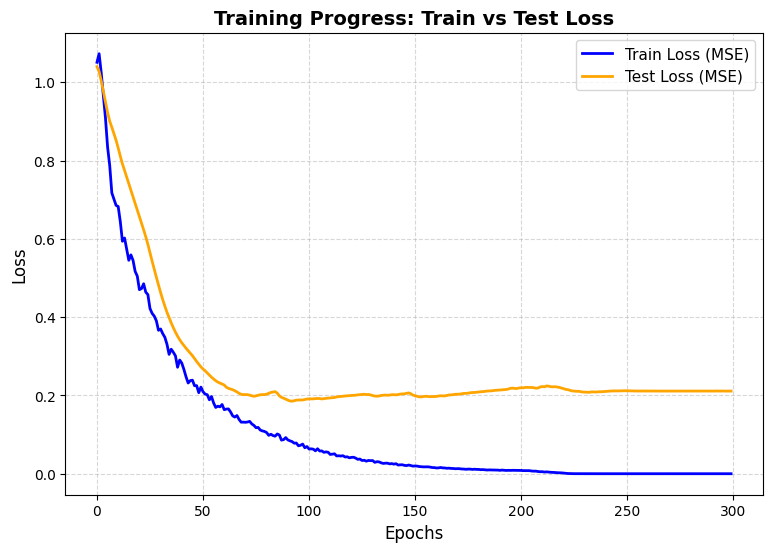

In [10]:
# Entrenar el modelo y obtener las pérdidas de entrenamiento y prueba
train_losses, test_losses = model.train_model_with_test_loss(train_loader, test_loader, num_epochs=300)

plt.figure(figsize=(9, 6))

# 2. Dibujar ambas líneas en el mismo lienzo
plt.plot(train_losses, label="Train Loss (MSE)", color="blue", linewidth=2)
plt.plot(test_losses, label="Test Loss (MSE)", color="orange", linewidth=2)

# 3. Añadir etiquetas, título y leyenda
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Progress: Train vs Test Loss", fontsize=14, fontweight='bold')

# La leyenda es crucial ahora para saber cuál es cuál
plt.legend(fontsize=11)

# Añadir una cuadrícula de fondo para que se lea mejor
plt.grid(True, linestyle="--", alpha=0.5)

# 4. Mostrar la gráfica final
plt.show()